# LogReg With Amount

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, confusion_matrix, PrecisionRecallDisplay
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [2]:
DROPPED = ['Class', 'Time', 'V23', 'V27', 'V28', 'V26', 'V25', 'V22', 'V15', 'V13', 'V24']
TOP_N    = 12        
MIN_FEATURES = 3     

In [3]:
df = pd.read_csv('creditcard.csv')
ALL_FEATURES = [c for c in df.columns if c not in DROPPED]
print(f"Available features ({len(ALL_FEATURES)}): {ALL_FEATURES}\n")

X_all = df[ALL_FEATURES]
y     = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42
)

def evaluate(features):
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_test[list(features)])
    y_probs = model.predict_proba(X_test[list(features)])[:, 1]
    return {
        'recall':    recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'pr_auc':    average_precision_score(y_test, y_probs),
    }

results = []

Available features (20): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'Amount']



## FORWARD STEPWISE RECALL

In [4]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["recall"]
        else:
            m = evaluate(candidate)
            score = m["recall"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…

  Added 'V12' → recall=0.8776  precision=0.0216  f1=0.0422  [1 features]
  Added 'V14' → recall=0.8980  precision=0.0620  f1=0.1160  [2 features]
  Added 'V4' → recall=0.9286  precision=0.0510  f1=0.0968  [3 features]
  Added 'V1' → recall=0.9286  precision=0.0525  f1=0.0994  [4 features]
  Added 'V2' → recall=0.9286  precision=0.0520  f1=0.0985  [5 features]
  Added 'V3' → recall=0.9286  precision=0.0516  f1=0.0978  [6 features]
  Added 'V5' → recall=0.9286  precision=0.0500  f1=0.0949  [7 features]
  Added 'V6' → recall=0.9286  precision=0.0499  f1=0.0947  [8 features]
  Added 'V7' → recall=0.9286  precision=0.0490  f1=0.0931  [9 features]
  Added 'V8' → recall=0.9286  precision=0.0485  f1=0.0922  [10 features]
  Added 'V9' → recall=0.9286  precision=0.0484  f1=0.0921  [11 features]
  Added 'V10' → recall=0.9286  precision=0.0550  f1=0.1038  [12 features]
  Added 'V11' → recall=0.9286  precision=0.0563  f1=0.1061  [13 features]
  Added 'V17' → recall=0.92

In [5]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALl")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_balanced_recall_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl
══════════════════════════════════════════════════════

Rank 1  (8 features)
  Recall:    0.9286
  Precision: 0.0524
  F1:        0.0992
  PR AUC:    0.6366
  Features:  ['V12', 'V14', 'V4', 'V1', 'V2', 'V3', 'V5', 'V11']

Rank 2  (14 features)
  Recall:    0.9286
  Precision: 0.0566
  F1:        0.1067
  PR AUC:    0.6772
  Features:  ['V12', 'V14', 'V4', 'V1', 'V2', 'V3', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V19']

Rank 3  (9 features)
  Recall:    0.9286
  Precision: 0.0493
  F1:        0.0936
  PR AUC:    0.6671
  Features:  ['V12', 'V14', 'V4', 'V1', 'V2', 'V3', 'V5', 'V6', 'V8']

Rank 4  (9 features)
  Recall:    0.9286
  Precision: 0.0497
  F1:        0.0943
  PR AUC:    0.6365
  Features:  ['V12', 'V14', 'V4', 'V1', 'V2', 'V3', 'V5', 'V6', 'V9']

Rank 5  (9 features)
  Recall:    0.9286
  Precision: 0.0564
  F1:        0.1063
  PR AUC:    0.6729
  Features:  ['V12', 'V14', 'V4', 'V1', 

## FORWARD STEPWISE PR AUC

In [6]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["pr_auc"]
        else:
            m = evaluate(candidate)
            score = m["pr_auc"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…

  Added 'V17' → recall=0.7755  precision=0.4551  f1=0.5736  [1 features]
  Added 'V14' → recall=0.8776  precision=0.0648  f1=0.1207  [2 features]
  Added 'V10' → recall=0.8878  precision=0.0668  f1=0.1243  [3 features]
  Added 'V8' → recall=0.8878  precision=0.0657  f1=0.1224  [4 features]
  Added 'V16' → recall=0.8878  precision=0.0659  f1=0.1226  [5 features]
  Added 'V2' → recall=0.8878  precision=0.0664  f1=0.1235  [6 features]
  Added 'V18' → recall=0.8878  precision=0.0660  f1=0.1228  [7 features]
  Added 'V7' → recall=0.8878  precision=0.0663  f1=0.1234  [8 features]
  Added 'V5' → recall=0.8878  precision=0.0618  f1=0.1155  [9 features]
  Added 'V9' → recall=0.8980  precision=0.0680  f1=0.1264  [10 features]
  Added 'V12' → recall=0.8980  precision=0.0614  f1=0.1149  [11 features]
  Added 'V4' → recall=0.9184  precision=0.0545  f1=0.1030  [12 features]
  Added 'V21' → recall=0.9184  precision=0.0536  f1=0.1014  [13 features]
  Added 'V19' → recall=0

In [7]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_balanced_pr_auc_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC
══════════════════════════════════════════════════════

Rank 1  (17 features)
  Recall:    0.9286
  Precision: 0.0559
  F1:        0.1054
  PR AUC:    0.7451
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V2', 'V18', 'V7', 'V5', 'V9', 'V12', 'V4', 'V21', 'V19', 'V1', 'V3', 'V6']

Rank 2  (13 features)
  Recall:    0.9184
  Precision: 0.0536
  F1:        0.1014
  PR AUC:    0.7445
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V2', 'V18', 'V7', 'V5', 'V9', 'V12', 'V4', 'V21']

Rank 3  (16 features)
  Recall:    0.9286
  Precision: 0.0545
  F1:        0.1029
  PR AUC:    0.7444
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V2', 'V18', 'V7', 'V5', 'V9', 'V12', 'V4', 'V21', 'V19', 'V1', 'V3']

Rank 4  (12 features)
  Recall:    0.9184
  Precision: 0.0545
  F1:        0.1030
  PR AUC:    0.7442
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V2', 'V18', 'V7', 'V5', 'V9', 'V12', 'V4']

Rank 5  (14 f

## TOP N RECALL

In [8]:
print("Ranking features by logistic regression importance…")
base_model = LogisticRegression(max_iter=1000, class_weight='balanced')
base_model.fit(X_train, y_train)
importances = pd.Series(np.abs(base_model.coef_[0]), index=ALL_FEATURES)
top_features = importances.nlargest(TOP_N).index.tolist()
print(f"Top {TOP_N} features: {top_features}\n")

total = sum(1 for k in range(MIN_FEATURES, len(top_features)+1)
            for _ in combinations(top_features, k))
print(f"Exhaustive search over top {TOP_N}: {total:,} combinations…\n")
done = 0
for k in range(MIN_FEATURES, len(top_features) + 1):
    for combo in combinations(top_features, k):
        metrics = evaluate(combo)
        results.append({'features': list(combo), **metrics})
        done += 1
        if done % 200 == 0:
            print(f"  {done:,} / {total:,} done…")

Ranking features by logistic regression importance…
Top 12 features: ['V14', 'V10', 'V4', 'V16', 'V12', 'V17', 'V20', 'V8', 'V11', 'V5', 'V1', 'V6']

Exhaustive search over top 12: 4,017 combinations…

  200 / 4,017 done…
  400 / 4,017 done…
  600 / 4,017 done…
  800 / 4,017 done…
  1,000 / 4,017 done…
  1,200 / 4,017 done…
  1,400 / 4,017 done…


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALl")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_balanced_recall_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl
══════════════════════════════════════════════════════

Rank 1  (6 features)
  Recall:    0.9286
  Precision: 0.0490
  F1:        0.0930
  PR AUC:    0.6903
  Features:  ['V4', 'V14', 'V12', 'V8', 'V5', 'V21']

Rank 2  (7 features)
  Recall:    0.9286
  Precision: 0.0549
  F1:        0.1037
  PR AUC:    0.6892
  Features:  ['V4', 'V14', 'V12', 'V8', 'V11', 'V20', 'V5']

Rank 3  (4 features)
  Recall:    0.9286
  Precision: 0.0511
  F1:        0.0968
  PR AUC:    0.6774
  Features:  ['V4', 'V14', 'V12', 'V21']

Rank 4  (4 features)
  Recall:    0.9286
  Precision: 0.0525
  F1:        0.0994
  PR AUC:    0.6667
  Features:  ['V4', 'V14', 'V12', 'V1']

Rank 5  (7 features)
  Recall:    0.9286
  Precision: 0.0491
  F1:        0.0932
  PR AUC:    0.6931
  Features:  ['V4', 'V14', 'V12', 'V8', 'V20', 'V5', 'V21']

Rank 6  (7 features)
  Recall:    0.9286
  Precision: 0.0545
  F1:        0.1029
  PR AUC:    

In [ ]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_balanced_pr_auc_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC
══════════════════════════════════════════════════════

Rank 1  (9 features)
  Recall:    0.9184
  Precision: 0.0560
  F1:        0.1056
  PR AUC:    0.7488
  Features:  ['V4', 'V10', 'V16', 'V14', 'V12', 'V8', 'V17', 'V5', 'V21']

Rank 2  (10 features)
  Recall:    0.9184
  Precision: 0.0569
  F1:        0.1071
  PR AUC:    0.7472
  Features:  ['V4', 'V10', 'V16', 'V14', 'V12', 'V8', 'V17', 'V20', 'V5', 'V21']

Rank 3  (11 features)
  Recall:    0.9184
  Precision: 0.0562
  F1:        0.1059
  PR AUC:    0.7467
  Features:  ['V4', 'V10', 'V16', 'V14', 'V12', 'V8', 'V11', 'V20', 'V5', 'V21', 'V1']

Rank 4  (10 features)
  Recall:    0.9184
  Precision: 0.0574
  F1:        0.1080
  PR AUC:    0.7461
  Features:  ['V4', 'V10', 'V16', 'V14', 'V12', 'V8', 'V17', 'V5', 'V21', 'V1']

Rank 5  (10 features)
  Recall:    0.9184
  Precision: 0.0557
  F1:        0.1050
  PR AUC:    0.7460
  Features:  ['V4', 'V1

# Compare the results

In [ ]:
forward_stepwise_recall = pd.read_csv('csv_new/logreg_fs_balanced_recall.csv')
top_n_recall = pd.read_csv('csv_new/logreg_top_n_balanced_recall.csv')

forward_stepwise_recall_amount = pd.read_csv('csv_new/logreg_fs_balanced_recall_amount.csv')
top_n_recall_amount = pd.read_csv('csv_new/logreg_top_n_balanced_recall_amount.csv')

print("\n══════════════════════════════════════════════════════")
print("BEST OF RECALL — SIDE BY SIDE")
print("══════════════════════════════════════════════════════")
metrics = ['recall', 'precision', 'f1', 'pr_auc']
summary = pd.DataFrame({
    'Metric': metrics,
    'Forward_Stepwise': [forward_stepwise_recall[m].iloc[0] for m in metrics],
    'Top_N': [top_n_recall[m].iloc[0] for m in metrics],
    'Forward_Stepwise_With_Amount': [forward_stepwise_recall_amount[m].iloc[0] for m in metrics],
    'Top_N_With_Amount': [top_n_recall_amount[m].iloc[0] for m in metrics],
})
cols = ['Forward_Stepwise', 'Top_N', 'Forward_Stepwise_With_Amount', 'Top_N_With_Amount']
summary['Best_Value'] = summary[cols].max(axis=1)
summary['Winner'] = summary[cols].idxmax(axis=1)

print(summary.to_string(index=False))


══════════════════════════════════════════════════════
BEST OF RECALL — SIDE BY SIDE
══════════════════════════════════════════════════════
   Metric  Forward_Stepwise    Top_N  Difference Winner
   recall          0.928571 0.928571    0.000000    Tie
precision          0.048925 0.048951    0.000026  Top_N
       f1          0.092952 0.092999    0.000047  Top_N
   pr_auc          0.631506 0.690323    0.058817  Top_N


In [ ]:
forward_stepwise_recall = pd.read_csv('csv_new/logreg_fs_balanced_pr_auc.csv')
top_n_recall = pd.read_csv('csv_new/logreg_top_n_balanced_pr_auc.csv')

forward_stepwise_pr_auc_amount = pd.read_csv('csv_new/logreg_fs_balanced_pr_auc_amount.csv')
top_n_pr_auc_amount = pd.read_csv('csv_new/logreg_top_n_balanced_pr_auc_amount.csv')

print("\n══════════════════════════════════════════════════════")
print("BEST OF PR AUC — SIDE BY SIDE")
print("══════════════════════════════════════════════════════")
metrics = ['recall', 'precision', 'f1', 'pr_auc']
summary = pd.DataFrame({
    'Metric': metrics,
    'Forward_Stepwise': [forward_stepwise_recall[m].iloc[0] for m in metrics],
    'Top_N': [top_n_recall[m].iloc[0] for m in metrics],
    'Forward_Stepwise_With_Amount': [forward_stepwise_recall[m].iloc[0] for m in metrics],
    'Top_N_With_Amount': [top_n_recall[m].iloc[0] for m in metrics],
})
cols = ['Forward_Stepwise', 'Top_N', 'Forward_Stepwise_With_Amount', 'Top_N_With_Amount']
summary['Best_Value'] = summary[cols].max(axis=1)
summary['Winner'] = summary[cols].idxmax(axis=1)

print(summary.to_string(index=False))


══════════════════════════════════════════════════════
BEST OF PR AUC — SIDE BY SIDE
══════════════════════════════════════════════════════
   Metric  Forward_Stepwise    Top_N  Difference           Winner
   recall          0.928571 0.918367   -0.010204 Forward_Stepwise
precision          0.055897 0.056005    0.000108            Top_N
       f1          0.105446 0.105572    0.000126            Top_N
   pr_auc          0.745127 0.748788    0.003661            Top_N


# Generate HeatMap

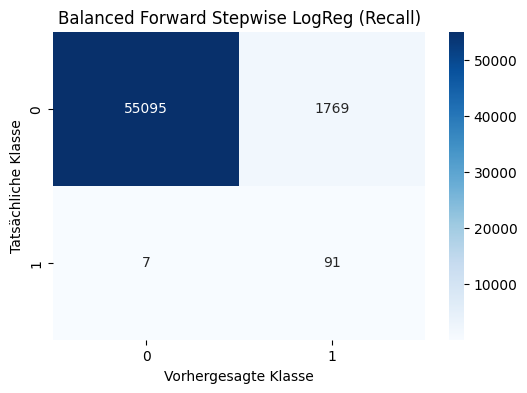

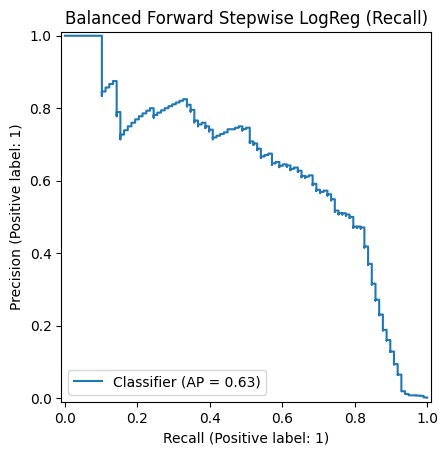

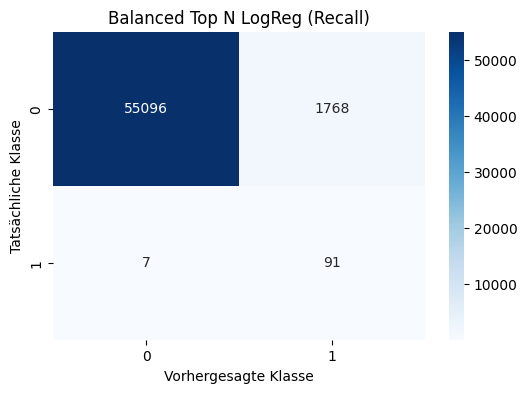

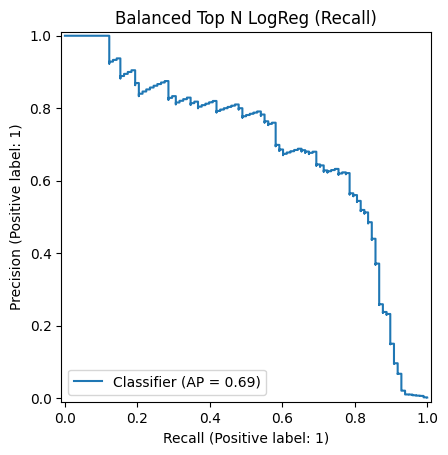

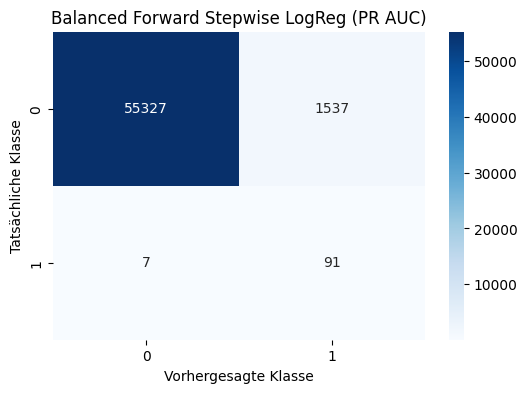

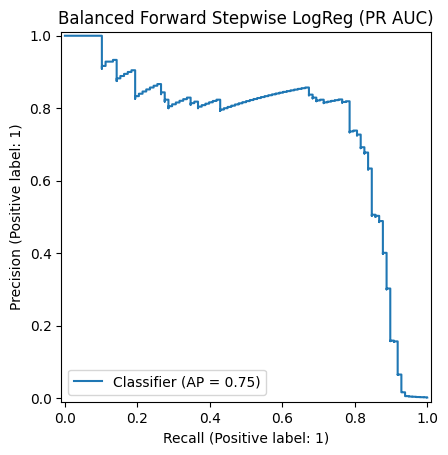

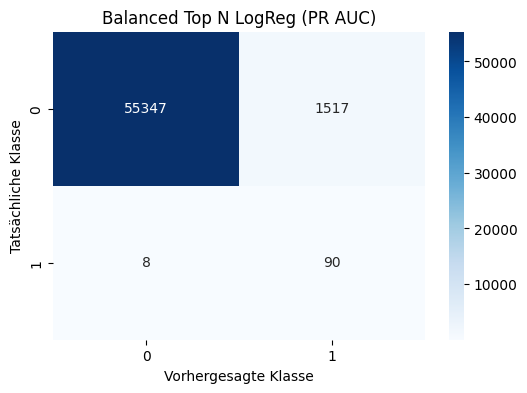

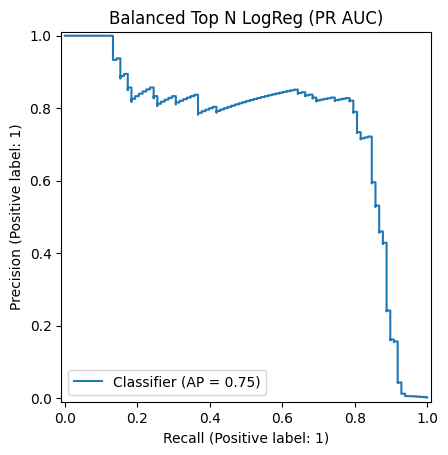

In [ ]:
def evaluate(features, title):
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_test[list(features)])
    y_probs = model.predict_proba(X_test[list(features)])[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Tatsächliche Klasse')
    plt.xlabel('Vorhergesagte Klasse')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_probs)
    plt.title(title)
    plt.show()

evaluate(ast.literal_eval(forward_stepwise_recall_amount['features'].iloc[0]), "Balanced Forward Stepwise LogReg (Recall)")
evaluate(ast.literal_eval(top_n_recall_amount['features'].iloc[0]), "Balanced Top N LogReg (Recall)")

evaluate(ast.literal_eval(forward_stepwise_pr_auc_amount['features'].iloc[0]), "Balanced Forward Stepwise LogReg (PR AUC)")
evaluate(ast.literal_eval(top_n_pr_auc_amount['features'].iloc[0]), "Balanced Top N LogReg (PR AUC)")


